# KNN from scratch #

Importing lib


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

dataset with 2 feature and 1 label

In [1]:
# [Feature1, Feature2, Label]
data = [
    [2.1, 7.8, "Apple"],
    [2.5, 8.3, "Apple"],
    [3.0, 7.2, "Apple"],
    [3.4, 8.0, "Apple"],
    [3.8, 6.8, "Apple"],
    [4.1, 7.5, "Apple"],
    [4.5, 6.9, "Apple"],

    [6.5, 2.2, "Banana"],
    [7.0, 2.8, "Banana"],
    [7.6, 3.4, "Banana"],
    [8.2, 2.5, "Banana"],
    [8.6, 3.1, "Banana"],
    [7.8, 4.0, "Banana"],
    [6.9, 3.7, "Banana"],

    [6.0, 7.2, "Pineapple"],
    [6.5, 6.5, "Pineapple"],
    [7.0, 7.8, "Pineapple"],
    [7.8, 6.8, "Pineapple"],
    [8.2, 7.5, "Pineapple"],
    [8.8, 6.9, "Pineapple"],
    [7.3, 8.4, "Pineapple"],

    [3.2, 3.5, "Orange"],
    [3.8, 2.7, "Orange"],
    [4.4, 3.3, "Orange"],
    [4.9, 2.5, "Orange"],
    [5.2, 3.8, "Orange"],
    [4.7, 4.4, "Orange"],
    [3.6, 4.1, "Orange"],

    # Intentional overlap (harder points)
    [5.0, 6.0, "Apple"],
    [5.5, 5.8, "Pineapple"],
    [5.6, 4.7, "Orange"],
    [6.0, 4.5, "Banana"],
    [5.8, 5.2, "Orange"],
    [6.2, 5.6, "Pineapple"],
    [4.9, 5.4, "Apple"],
    [6.4, 5.0, "Banana"]
]

Model (only for two feature dataset)

In [99]:
def KNN(new_point,data,K):
    distance = []
    #iterating over each row in data
    for row in data:
            # Calculating euclid distance of new_point from each row's feature
            dist = math.sqrt(((row[0]-new_point[0])**2)+((row[1]-new_point[1])**2))
            distance.append([row[2],dist])

            # Sorting the distance in ascending order
            sorted_distance = sorted(distance, key=lambda row: row[1])
            
    #converting the sorted_distance nested list into df and only storing the elements upto K
    df = pd.DataFrame(sorted_distance[:K])
    voted = df[0].mode()
    print(voted)
    return df  

Inference

In [ ]:
new_point = [5.3, 5.6]
KNN(new_point,data,12)

# Visualization #

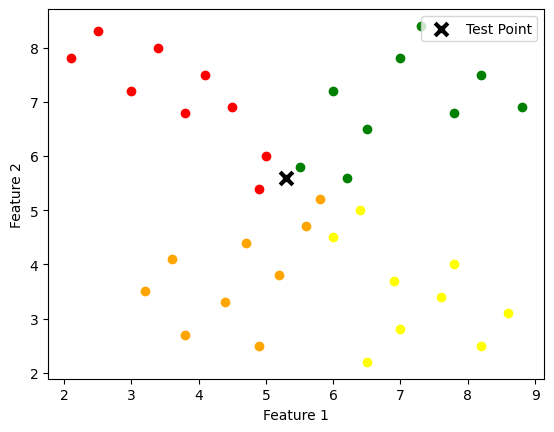

In [109]:
colors = {
    "Apple": "red",
    "Banana": "yellow",
    "Orange": "orange",
    "Pineapple": "green"
}

# Plot training data
for row in data:
    plt.scatter(row[0], row[1], color=colors[row[2]])

# Plot the new point
plt.scatter(
    new_point[0],
    new_point[1],
    color="black",
    marker="X",      # Different marker
    s=200,           # Bigger size
    edgecolors="white",
    linewidth=2,
    label="Test Point"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Model for n feature dataset (last column should be labels)

In [2]:
def KNN_multi_feature(new_point, df, K):
    distances = []
    new_point = np.array(new_point)

    if "Id" in df.columns:
        df = df.drop(columns=["Id"])

    # formula for Euclidean distance
    for _, row in df.iterrows():
        arr = row.to_numpy()
        diff = new_point - arr[:-1]      # use new_point instead of test_data
        squared = diff ** 2
        distance = np.sqrt(np.sum(squared))
        distances.append(distance)

    distances = np.array(distances)

    # Create a DataFrame with distances and labels
    results = pd.DataFrame({
        "Distance": distances,
        "Label": df.iloc[:, -1]
    })

    # Sort by distance
    results = results.sort_values(by="Distance")

    # First K labels
    k_labels = results["Label"].head(K)
    return(k_labels.mode().iloc[0])

## Iris dataset ##

load dataset

In [37]:
iris_df = pd.read_csv("dataset/Iris.csv")

inference(singel point)

In [ ]:
test_data = [5.1, 3.5, 1.4, 0.2]
KNN_multi_feature(test_data, iris_df, 9)

'Iris-setosa'

Inference(multiple points)

In [6]:
test_cases = [
    [[5.1, 3.5, 1.4, 0.2], "Setosa"],
    [[4.9, 3.0, 1.4, 0.2], "Setosa"],
    [[5.0, 3.4, 1.5, 0.2], "Setosa"],

    [[6.0, 2.9, 4.5, 1.5], "Versicolor"],
    [[5.7, 2.8, 4.1, 1.3], "Versicolor"],
    [[6.4, 3.2, 4.5, 1.5], "Versicolor"],

    [[6.5, 3.0, 5.5, 1.8], "Virginica"],
    [[7.2, 3.6, 6.1, 2.5], "Virginica"],
    [[6.8, 3.0, 5.5, 2.1], "Virginica"],

    # Boundary cases
    [[6.0, 2.7, 5.1, 1.6], "Virginica"],
    [[6.3, 2.8, 5.0, 1.5], "Virginica"],
    [[5.9, 3.0, 4.2, 1.5], "Versicolor"],

    # Out-of-distribution
    [[8.0, 4.0, 7.0, 3.0], "Virginica"],
    [[3.5, 2.0, 1.0, 0.1], "Setosa"],
    [[5.8, 4.5, 2.0, 0.5], "Setosa"],
]
iris_data = pd.read_csv("dataset/Iris.csv")

comparison = []
for features, expected in test_cases:
    prediction = KNN_multi_feature(features, iris_df,9)
    comparison.append([expected, prediction])
comparison_df = pd.DataFrame(comparison,columns=["Expected", "Prediction"])
print(comparison_df)

      Expected       Prediction
0       Setosa      Iris-setosa
1       Setosa      Iris-setosa
2       Setosa      Iris-setosa
3   Versicolor  Iris-versicolor
4   Versicolor  Iris-versicolor
5   Versicolor  Iris-versicolor
6    Virginica   Iris-virginica
7    Virginica   Iris-virginica
8    Virginica   Iris-virginica
9    Virginica   Iris-virginica
10   Virginica  Iris-versicolor
11  Versicolor  Iris-versicolor
12   Virginica   Iris-virginica
13      Setosa      Iris-setosa
14      Setosa      Iris-setosa


# KNN with Scikit Learn ##

In [66]:
dataset = iris_df.drop(columns="Id")
x = dataset.iloc[:,:4].values
y = dataset.iloc[:,-1:].values

Test train split

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20)

array([[5.7, 2.9, 4.2, 1.3],
       [4.6, 3.1, 1.5, 0.2],
       [6. , 3. , 4.8, 1.8],
       [4.6, 3.6, 1. , 0.2],
       [5. , 3.5, 1.3, 0.3],
       [5.7, 2.8, 4.5, 1.3],
       [6.1, 2.8, 4. , 1.3],
       [5.2, 2.7, 3.9, 1.4],
       [5.2, 4.1, 1.5, 0.1],
       [6.5, 3. , 5.8, 2.2],
       [6. , 3.4, 4.5, 1.6],
       [6.5, 2.8, 4.6, 1.5],
       [6.3, 3.3, 4.7, 1.6],
       [5.5, 2.6, 4.4, 1.2],
       [6.6, 3. , 4.4, 1.4],
       [6.1, 2.6, 5.6, 1.4],
       [6.1, 3. , 4.6, 1.4],
       [5.6, 2.9, 3.6, 1.3],
       [5.7, 2.6, 3.5, 1. ],
       [5.5, 2.3, 4. , 1.3],
       [5.1, 3.4, 1.5, 0.2],
       [5.7, 3. , 4.2, 1.2],
       [4.8, 3.4, 1.6, 0.2],
       [5.8, 2.7, 3.9, 1.2],
       [7.6, 3. , 6.6, 2.1],
       [7.1, 3. , 5.9, 2.1],
       [6.7, 3.3, 5.7, 2.5],
       [5.4, 3.9, 1.3, 0.4],
       [7.7, 3.8, 6.7, 2.2],
       [5. , 3.5, 1.6, 0.6],
       [6.4, 3.1, 5.5, 1.8],
       [5.2, 3.5, 1.5, 0.2],
       [5.1, 3.8, 1.5, 0.3],
       [6.1, 2.9, 4.7, 1.4],
       [4.9, 2

feature normalization

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)


In [71]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train,y_train)

C:\Users\Plastic\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [73]:
y_pred = classifier.predict(x_test) 

In [77]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         9
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

[[ 9  0  0]
 [ 0  9  1]
 [ 0  0 11]]
